In [29]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [30]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
movies = pd.read_csv('data/movies.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Movies shape:", movies.shape)
print("\nTrain sample:")
train.head()

Train shape: (10000038, 4)
Test shape: (5000019, 2)
Movies shape: (62423, 3)

Train sample:


,userId,movieId,rating,timestamp
0,5163,57669,4.0,1518349992
1,106343,5,4.5,1206238739
2,146790,5459,5.0,1076215539
3,106362,32296,2.0,1423042565
4,9041,366,3.0,833375837


In [31]:
## Getting the basic statistiques of the dataset
print("Rating Distribution:")
print(train['rating'].describe())
print("\nUnique users:", train['userId'].nunique())
print("Unique movies:", train['movieId'].nunique())
print("Total ratings:", len(train))
print("\nRating value counts:")
print(train['rating'].value_counts().sort_index())

Rating Distribution:
count    1.000004e+07
mean     3.533395e+00
std      1.061124e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

Unique users: 162541
Unique movies: 48213
Total ratings: 10000038

Rating value counts:
rating
0.5     157571
1.0     311213
1.5     159731
2.0     656821
2.5     505578
3.0    1959759
3.5    1270642
4.0    2652977
4.5     880516
5.0    1445230
Name: count, dtype: int64


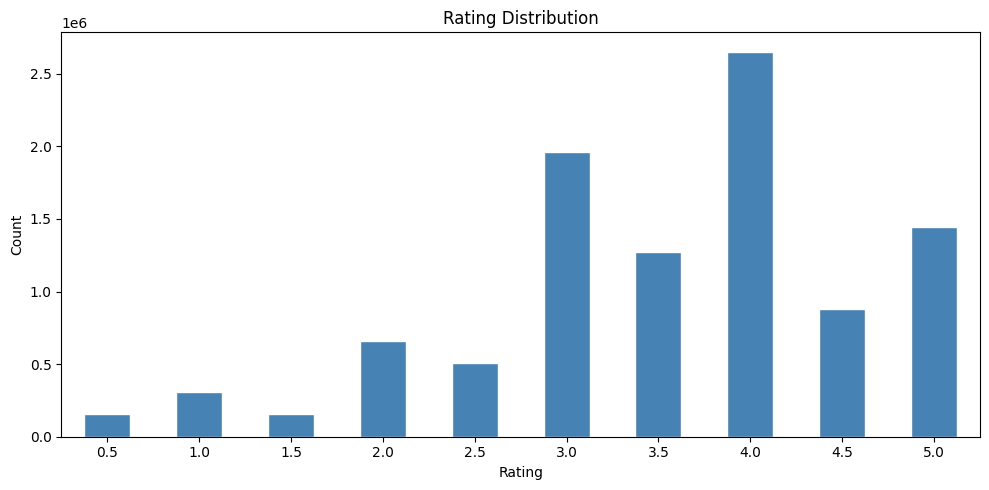

In [32]:
## Rating distribution plot
plt.figure(figsize=(10, 5))
train['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

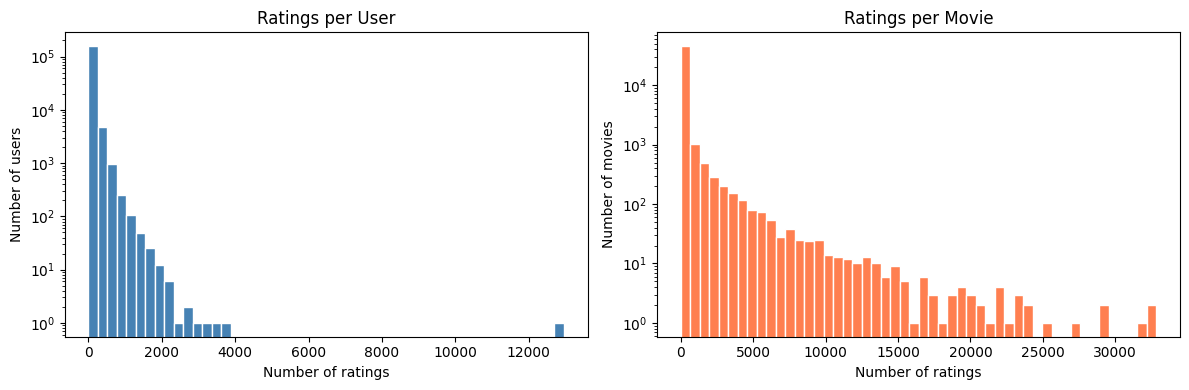

Most active user rated 12952 movies
Least active user rated 1 movies
Most rated movie has 32831 ratings
Least rated movie has 1 ratings

Median ratings per user: 28.0
Median ratings per movie: 4.0


In [33]:
user_counts = train.groupby('userId')['rating'].count()
movie_counts = train.groupby('movieId')['rating'].count()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(user_counts, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Ratings per User')
axes[0].set_xlabel('Number of ratings')
axes[0].set_ylabel('Number of users')
axes[0].set_yscale('log')

axes[1].hist(movie_counts, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Ratings per Movie')
axes[1].set_xlabel('Number of ratings')
axes[1].set_ylabel('Number of movies')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print(f"Most active user rated {user_counts.max()} movies")
print(f"Least active user rated {user_counts.min()} movies")
print(f"Most rated movie has {movie_counts.max()} ratings")
print(f"Least rated movie has {movie_counts.min()} ratings")
print(f"\nMedian ratings per user: {user_counts.median()}")
print(f"Median ratings per movie: {movie_counts.median()}")

In [34]:
"""Baseline model (global mean + user bias + movie bias)
This is our first real model. It's simple but surprisingly strong — many Kaggle winners use this as a component even in their final ensemble.
The idea: predict each rating as global_mean + user_bias + movie_bias. 
User bias captures whether a user rates high or low generally. Movie bias captures whether a movie is rated high or low generally."""

# Global mean
global_mean = train['rating'].mean()
print(f"Global mean rating: {global_mean:.4f}")

# User bias — how much each user deviates from global mean on average
user_bias = train.groupby('userId')['rating'].mean() - global_mean

# Movie bias — how much each movie deviates from global mean on average
movie_bias = train.groupby('movieId')['rating'].mean() - global_mean

print(f"\nUser bias range: {user_bias.min():.3f} to {user_bias.max():.3f}")
print(f"Movie bias range: {movie_bias.min():.3f} to {movie_bias.max():.3f}")


Global mean rating: 3.5334

User bias range: -3.033 to 1.467
Movie bias range: -3.033 to 1.467


In [35]:
## Generate predicitions and submission file 

# Load test file
test = pd.read_csv('data/test.csv')

# Map biases onto test set
test['user_bias'] = test['userId'].map(user_bias).fillna(0)
test['movie_bias'] = test['movieId'].map(movie_bias).fillna(0)

# Predict
test['rating'] = global_mean + test['user_bias'] + test['movie_bias']

# Clip to valid rating range
test['rating'] = test['rating'].clip(0.5, 5.0)

# Build submission
test['Id'] = test['userId'].astype(str) + '_' + test['movieId'].astype(str)
submission = test[['Id', 'rating']]

submission.to_csv('data/submission_baseline.csv', index=False)
print("Submission file saved")
print(f"Shape: {submission.shape}")
print(f"\nSample predictions:")
submission.head(10)


Submission file saved
Shape: (5000019, 2)

Sample predictions:


,Id,rating
0,1_2011,3.926269
1,1_4144,4.421179
2,1_5767,3.932875
3,1_6711,4.164132
4,1_7318,3.487435
5,1_8405,4.071398
6,1_8786,4.221581
7,2_150,3.746887
8,2_356,3.930488
9,2_497,3.765551


In [36]:
user_bias = train.groupby('userId')['rating'].mean() - global_mean
movie_bias = train.groupby('movieId')['rating'].mean() - global_mean

In [37]:
print(user_bias.head())
print(movie_bias.head())

userId
1    0.377319
2   -0.116729
3    0.157840
4   -0.224406
5    0.352319
Name: rating, dtype: float64
movieId
1    0.356575
2   -0.269981
3   -0.401070
4   -0.655296
5   -0.474230
Name: rating, dtype: float64


Our current model has an issue. it only knows two things about each prediction. How generous the user is and how good the movie is . It knows nothing about the taste. It cant tell that a user loves one movie but hates the other. It treates every user-movie combination the same way, just shifted by two bias numbers. We are fixing that.


In [38]:
## Reguarization of the model 

from sklearn.model_selection import train_test_split

# Split train into train/validation so we can measure improvement
train_data, val_data = train_test_split(train, test_size=0.1, random_state=42)

print(f"Training on {len(train_data):,} ratings")
print(f"Validating on {len(val_data):,} ratings")

Training on 9,000,034 ratings
Validating on 1,000,004 ratings


In [39]:
### RMSE FUNCTION 

def rmse(actual, predicted):
    errors = actual - predicted 
    squared_errors = errors ** 2
    mean_squared_error = squared_errors.mean()
    return np.sqrt(mean_squared_error)



In [40]:
# Quick sanity check
fake_actual = pd.Series([4.0, 3.0, 5.0, 2.0])
fake_predicted = pd.Series([3.8, 3.6, 4.2, 2.3])
print(f"Test RMSE: {rmse(fake_actual, fake_predicted):.4f}")

Test RMSE: 0.5315


In [41]:
lambda_reg = 15  # regularisation strength

# Global mean on training data only
global_mean = train_data['rating'].mean()

# Regularised user bias
user_stats = train_data.groupby('userId')['rating'].agg(['sum', 'count'])
user_bias = (user_stats['sum'] - global_mean * user_stats['count']) / (user_stats['count'] + lambda_reg)

# Regularised movie bias
movie_stats = train_data.groupby('movieId')['rating'].agg(['sum', 'count'])
movie_bias = (movie_stats['sum'] - global_mean * movie_stats['count']) / (movie_stats['count'] + lambda_reg)

print(f"Global mean: {global_mean:.4f}")
print(f"User bias range: {user_bias.min():.3f} to {user_bias.max():.3f}")
print(f"Movie bias range: {movie_bias.min():.3f} to {movie_bias.max():.3f}")

Global mean: 3.5335
User bias range: -2.667 to 1.455
Movie bias range: -2.310 to 0.946


In [42]:
### Validating the regularised model on the validation set

# Map biases onto validation set
val_data = val_data.copy()
val_data['user_bias'] = val_data['userId'].map(user_bias).fillna(0)
val_data['movie_bias'] = val_data['movieId'].map(movie_bias).fillna(0)

# Predict
val_data['predicted'] = global_mean + val_data['user_bias'] + val_data['movie_bias']
val_data['predicted'] = val_data['predicted'].clip(0.5, 5.0)

# Measure
score = rmse(val_data['rating'], val_data['predicted'])
print(f"Regularised bias model RMSE: {score:.4f}")

Regularised bias model RMSE: 0.8799


In [43]:
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

# Step 1 — build compact indices for users and movies
user_ids = train_data['userId'].unique()
movie_ids = train_data['movieId'].unique()

user_to_idx = {uid: idx for idx, uid in enumerate(user_ids)}
movie_to_idx = {mid: idx for idx, mid in enumerate(movie_ids)}

print(f"Users: {len(user_ids):,}")
print(f"Movies: {len(movie_ids):,}")
print(f"Matrix size: {len(user_ids):,} x {len(movie_ids):,}")

Users: 162,541
Movies: 46,901
Matrix size: 162,541 x 46,901


In [44]:
# Map userIds and movieIds to compact indices
row_idx = train_data['userId'].map(user_to_idx)
col_idx = train_data['movieId'].map(movie_to_idx)

# Use bias-adjusted ratings — remove user and movie bias before factorization
train_data = train_data.copy()
train_data['user_bias'] = train_data['userId'].map(user_bias).fillna(0)
train_data['movie_bias'] = train_data['movieId'].map(movie_bias).fillna(0)
train_data['adjusted_rating'] = train_data['rating'] - global_mean - train_data['user_bias'] - train_data['movie_bias']

# Build sparse matrix
rating_matrix = csr_matrix(
    (train_data['adjusted_rating'], (row_idx, col_idx)),
    shape=(len(user_ids), len(movie_ids))
)

print(f"Matrix shape: {rating_matrix.shape}")
print(f"Stored values: {rating_matrix.nnz:,}")
print(f"Sparsity: {100 * (1 - rating_matrix.nnz / (rating_matrix.shape[0] * rating_matrix.shape[1])):.2f}%")

Matrix shape: (162541, 46901)
Stored values: 9,000,034
Sparsity: 99.88%


In [45]:
print("Running SVD... this may take a few minutes")

K = 200  # number of latent features

U, sigma, Vt = svds(rating_matrix, k=K)

# Convert sigma to diagonal matrix
sigma = np.diag(sigma)

print(f"U shape (users x features): {U.shape}")
print(f"Sigma shape: {sigma.shape}")
print(f"Vt shape (features x movies): {Vt.shape}")
print("SVD complete")

Running SVD... this may take a few minutes
U shape (users x features): (162541, 200)
Sigma shape: (200, 200)
Vt shape (features x movies): (200, 46901)
SVD complete


In [46]:
# Precompute U × sigma once
U_sigma = np.dot(U, sigma)  # shape: (162541, 50) — manageable

def predict_svd(user_idx_series, movie_idx_series):
    predictions = np.zeros(len(user_idx_series))
    known_mask = user_idx_series.notna() & movie_idx_series.notna()
    
    u_idx = user_idx_series[known_mask].astype(int).values
    m_idx = movie_idx_series[known_mask].astype(int).values
    
    # Only compute dot product for needed pairs
    predictions[known_mask] = np.sum(
        U_sigma[u_idx] * Vt.T[m_idx], axis=1
    )
    return predictions

# Validate
val_data = val_data.copy()
val_user_idx = val_data['userId'].map(user_to_idx)
val_movie_idx = val_data['movieId'].map(movie_to_idx)

val_data['svd_component'] = predict_svd(val_user_idx, val_movie_idx)
val_data['user_bias'] = val_data['userId'].map(user_bias).fillna(0)
val_data['movie_bias'] = val_data['movieId'].map(movie_bias).fillna(0)
val_data['predicted'] = global_mean + val_data['user_bias'] + val_data['movie_bias'] + val_data['svd_component']
val_data['predicted'] = val_data['predicted'].clip(0.5, 5.0)

score = rmse(val_data['rating'], val_data['predicted'])
print(f"SVD model RMSE: {score:.4f}")
print(f"Improvement over bias model: {0.8799 - score:.4f}")

SVD model RMSE: 0.8685
Improvement over bias model: 0.0114


In [47]:
test = pd.read_csv('data/test.csv')

test_user_idx = test['userId'].map(user_to_idx)
test_movie_idx = test['movieId'].map(movie_to_idx)

test['svd_component'] = predict_svd(test_user_idx, test_movie_idx)
test['user_bias'] = test['userId'].map(user_bias).fillna(0)
test['movie_bias'] = test['movieId'].map(movie_bias).fillna(0)
test['rating'] = global_mean + test['user_bias'] + test['movie_bias'] + test['svd_component']
test['rating'] = test['rating'].clip(0.5, 5.0)

test['Id'] = test['userId'].astype(str) + '_' + test['movieId'].astype(str)
submission = test[['Id', 'rating']]
submission.to_csv('data/submission_svd.csv', index=False)

print("Submission saved")
print(f"Shape: {submission.shape}")
print(f"\nSample:")
submission.head()

Submission saved
Shape: (5000019, 2)

Sample:


,Id,rating
0,1_2011,3.769984
1,1_4144,4.281583
2,1_5767,3.782210
3,1_6711,4.036261
4,1_7318,3.343348


In [48]:
##  Explore Additional Data 

movies = pd.read_csv('data/movies.csv')
imdb = pd.read_csv('data/imdb_data.csv')
tags = pd.read_csv('data/tags.csv')

print("Movies:")
print(movies.head(3))
print(f"Shape: {movies.shape}\n")

print("IMDB:")
print(imdb.head(3))
print(f"Shape: {imdb.shape}\n")
print(f"Columns: {imdb.columns.tolist()}\n")

print("Tags:")
print(tags.head(3))
print(f"Shape: {tags.shape}")


Movies:
   movieId                    title  \
0        1         Toy Story (1995)   
1        2           Jumanji (1995)   
2        3  Grumpier Old Men (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
Shape: (62423, 3)

IMDB:
   movieId                                         title_cast  \
0        1  Tom Hanks|Tim Allen|Don Rickles|Jim Varney|Wal...   
1        2  Robin Williams|Jonathan Hyde|Kirsten Dunst|Bra...   
2        3  Walter Matthau|Jack Lemmon|Sophia Loren|Ann-Ma...   

              director  runtime       budget                     plot_keywords  
0        John Lasseter     81.0  $30,000,000  toy|rivalry|cowboy|cgi animation  
1   Jonathan Hensleigh    104.0  $65,000,000  board game|adventurer|fight|game  
2  Mark Steven Johnson    101.0  $25,000,000        boat|lake|neighbor|rivalry  
Shape: (27278, 6)

Columns: [

In [49]:
## Feature Engineering 
# 1. Genre features
movies['genres'] = movies['genres'].fillna('')
genres_list = set()
for g in movies['genres']:
    for genre in g.split('|'):
        genres_list.add(genre)
genres_list.discard('(no genres listed)')
genres_list = sorted(genres_list)

for genre in genres_list:
    movies[f'genre_{genre}'] = movies['genres'].str.contains(genre).astype(int)

print(f"Genres extracted: {genres_list}")
print(f"Movies shape after genres: {movies.shape}")

Genres extracted: ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
Movies shape after genres: (62423, 22)


In [50]:
## Clean IMDB features
# Clean budget — remove $ and commas, convert to number
imdb['budget_clean'] = imdb['budget'].str.replace('$', '', regex=False)
imdb['budget_clean'] = imdb['budget_clean'].str.replace(',', '', regex=False)
imdb['budget_clean'] = pd.to_numeric(imdb['budget_clean'], errors='coerce').fillna(0)

# Runtime already numeric but fill missing
imdb['runtime'] = pd.to_numeric(imdb['runtime'], errors='coerce').fillna(0)

# Director rating — average rating per director
director_stats = train_data.merge(imdb[['movieId', 'director']], on='movieId', how='left')
director_avg = director_stats.groupby('director')['rating'].mean()
director_count = director_stats.groupby('director')['rating'].count()
imdb['director_avg_rating'] = imdb['director'].map(director_avg).fillna(global_mean)
imdb['director_count'] = imdb['director'].map(director_count).fillna(0)

print("IMDB features:")
print(imdb[['movieId', 'runtime', 'budget_clean', 'director_avg_rating', 'director_count']].head())

IMDB features:
   movieId  runtime  budget_clean  director_avg_rating  director_count
0        1     81.0    30000000.0             3.878963         25992.0
1        2    104.0    65000000.0             3.281001         29822.0
2        3    101.0    25000000.0             2.905143         11802.0
3        4    124.0    16000000.0             2.808940          1264.0
4        5    106.0    30000000.0             3.066476          4197.0


In [51]:
## Build the full feature table 

# Merge everything onto training data
features = train_data[['userId', 'movieId', 'rating']].copy()

# Add user and movie biases
features['user_bias'] = features['userId'].map(user_bias).fillna(0)
features['movie_bias'] = features['movieId'].map(movie_bias).fillna(0)

# Add user stats
user_mean = train_data.groupby('userId')['rating'].mean()
user_std = train_data.groupby('userId')['rating'].std().fillna(0)
user_count = train_data.groupby('userId')['rating'].count()
features['user_mean'] = features['userId'].map(user_mean).fillna(global_mean)
features['user_std'] = features['userId'].map(user_std).fillna(0)
features['user_count'] = features['userId'].map(user_count).fillna(0)

# Add movie stats
movie_mean = train_data.groupby('movieId')['rating'].mean()
movie_std = train_data.groupby('movieId')['rating'].std().fillna(0)
movie_count = train_data.groupby('movieId')['rating'].count()
features['movie_mean'] = features['movieId'].map(movie_mean).fillna(global_mean)
features['movie_std'] = features['movieId'].map(movie_std).fillna(0)
features['movie_count'] = features['movieId'].map(movie_count).fillna(0)

# Add SVD component
train_user_idx = features['userId'].map(user_to_idx)
train_movie_idx = features['movieId'].map(movie_to_idx)
features['svd_component'] = predict_svd(train_user_idx, train_movie_idx)

# Add genre features
genre_cols = [f'genre_{g}' for g in genres_list]
features = features.merge(movies[['movieId'] + genre_cols], on='movieId', how='left')

# Add IMDB features
imdb_cols = ['movieId', 'runtime', 'budget_clean', 'director_avg_rating', 'director_count']
features = features.merge(imdb[imdb_cols], on='movieId', how='left')
features['runtime'] = features['runtime'].fillna(0)
features['budget_clean'] = features['budget_clean'].fillna(0)
features['director_avg_rating'] = features['director_avg_rating'].fillna(global_mean)
features['director_count'] = features['director_count'].fillna(0)

print(f"Feature table shape: {features.shape}")
print(f"\nColumns: {features.columns.tolist()}")

Feature table shape: (9000034, 35)

Columns: ['userId', 'movieId', 'rating', 'user_bias', 'movie_bias', 'user_mean', 'user_std', 'user_count', 'movie_mean', 'movie_std', 'movie_count', 'svd_component', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Children', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Fantasy', 'genre_Film-Noir', 'genre_Horror', 'genre_IMAX', 'genre_Musical', 'genre_Mystery', 'genre_Romance', 'genre_Sci-Fi', 'genre_Thriller', 'genre_War', 'genre_Western', 'runtime', 'budget_clean', 'director_avg_rating', 'director_count']


In [52]:
## Train LightGBM

import lightgbm as lgb
from sklearn.model_selection import train_test_split

# Define features and target
feature_cols = [c for c in features.columns if c not in ['userId', 'movieId', 'rating']]
X = features[feature_cols]
y = features['rating']

print(f"Training LightGBM on {len(X):,} rows with {len(feature_cols)} features")
print(f"Features: {feature_cols}")

# Train LightGBM
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=127,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X, y,
    eval_set=[(X, y)],
    callbacks=[lgb.log_evaluation(period=100)]
)

print("\nTraining complete")

Training LightGBM on 9,000,034 rows with 32 features
Features: ['user_bias', 'movie_bias', 'user_mean', 'user_std', 'user_count', 'movie_mean', 'movie_std', 'movie_count', 'svd_component', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Children', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Fantasy', 'genre_Film-Noir', 'genre_Horror', 'genre_IMAX', 'genre_Musical', 'genre_Mystery', 'genre_Romance', 'genre_Sci-Fi', 'genre_Thriller', 'genre_War', 'genre_Western', 'runtime', 'budget_clean', 'director_avg_rating', 'director_count']
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.038936 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3184
[LightGBM] [Info] Number of data points in the train set: 9000034, number of used features: 32
[LightGBM] [Info] Start training from score 3.533494
[100]	training's l2: 0.346146
[200]	training's l2: 0.33485
[300]	training's l2:

In [53]:
## Validate LightGBM on validation set

# Build validation features
val_features = val_data[['userId', 'movieId', 'rating']].copy()

val_features['user_bias'] = val_features['userId'].map(user_bias).fillna(0)
val_features['movie_bias'] = val_features['movieId'].map(movie_bias).fillna(0)

val_features['user_mean'] = val_features['userId'].map(user_mean).fillna(global_mean)
val_features['user_std'] = val_features['userId'].map(user_std).fillna(0)
val_features['user_count'] = val_features['userId'].map(user_count).fillna(0)

val_features['movie_mean'] = val_features['movieId'].map(movie_mean).fillna(global_mean)
val_features['movie_std'] = val_features['movieId'].map(movie_std).fillna(0)
val_features['movie_count'] = val_features['movieId'].map(movie_count).fillna(0)

val_user_idx = val_features['userId'].map(user_to_idx)
val_movie_idx = val_features['movieId'].map(movie_to_idx)
val_features['svd_component'] = predict_svd(val_user_idx, val_movie_idx)

val_features = val_features.merge(movies[['movieId'] + genre_cols], on='movieId', how='left')
val_features = val_features.merge(imdb[imdb_cols], on='movieId', how='left')
val_features['runtime'] = val_features['runtime'].fillna(0)
val_features['budget_clean'] = val_features['budget_clean'].fillna(0)
val_features['director_avg_rating'] = val_features['director_avg_rating'].fillna(global_mean)
val_features['director_count'] = val_features['director_count'].fillna(0)

# Predict
X_val = val_features[feature_cols]
val_predictions = model.predict(X_val)
val_predictions = np.clip(val_predictions, 0.5, 5.0)

score = rmse(val_features['rating'], val_predictions)
print(f"LightGBM RMSE: {score:.4f}")
print(f"Improvement over SVD: {0.8685 - score:.4f}")
print(f"Improvement over baseline: {0.8799 - score:.4f}")

LightGBM RMSE: 0.8570
Improvement over SVD: 0.0115
Improvement over baseline: 0.0229


In [54]:
## Generate LightGBM submission
# Build test features
test = pd.read_csv('data/test.csv')

test['user_bias'] = test['userId'].map(user_bias).fillna(0)
test['movie_bias'] = test['movieId'].map(movie_bias).fillna(0)

test['user_mean'] = test['userId'].map(user_mean).fillna(global_mean)
test['user_std'] = test['userId'].map(user_std).fillna(0)
test['user_count'] = test['userId'].map(user_count).fillna(0)

test['movie_mean'] = test['movieId'].map(movie_mean).fillna(global_mean)
test['movie_std'] = test['movieId'].map(movie_std).fillna(0)
test['movie_count'] = test['movieId'].map(movie_count).fillna(0)

test_user_idx = test['userId'].map(user_to_idx)
test_movie_idx = test['movieId'].map(movie_to_idx)
test['svd_component'] = predict_svd(test_user_idx, test_movie_idx)

test = test.merge(movies[['movieId'] + genre_cols], on='movieId', how='left')
test = test.merge(imdb[imdb_cols], on='movieId', how='left')
test['runtime'] = test['runtime'].fillna(0)
test['budget_clean'] = test['budget_clean'].fillna(0)
test['director_avg_rating'] = test['director_avg_rating'].fillna(global_mean)
test['director_count'] = test['director_count'].fillna(0)

# Predict
X_test = test[feature_cols]
test['rating'] = model.predict(X_test)
test['rating'] = test['rating'].clip(0.5, 5.0)

test['Id'] = test['userId'].astype(str) + '_' + test['movieId'].astype(str)
submission = test[['Id', 'rating']]
submission.to_csv('data/submission_lgbm.csv', index=False)

print("Submission saved")
print(f"Shape: {submission.shape}")
submission.head()

Submission saved
Shape: (5000019, 2)


,Id,rating
0,1_2011,3.698305
1,1_4144,4.537559
2,1_5767,3.734217
3,1_6711,4.177085
4,1_7318,2.511813


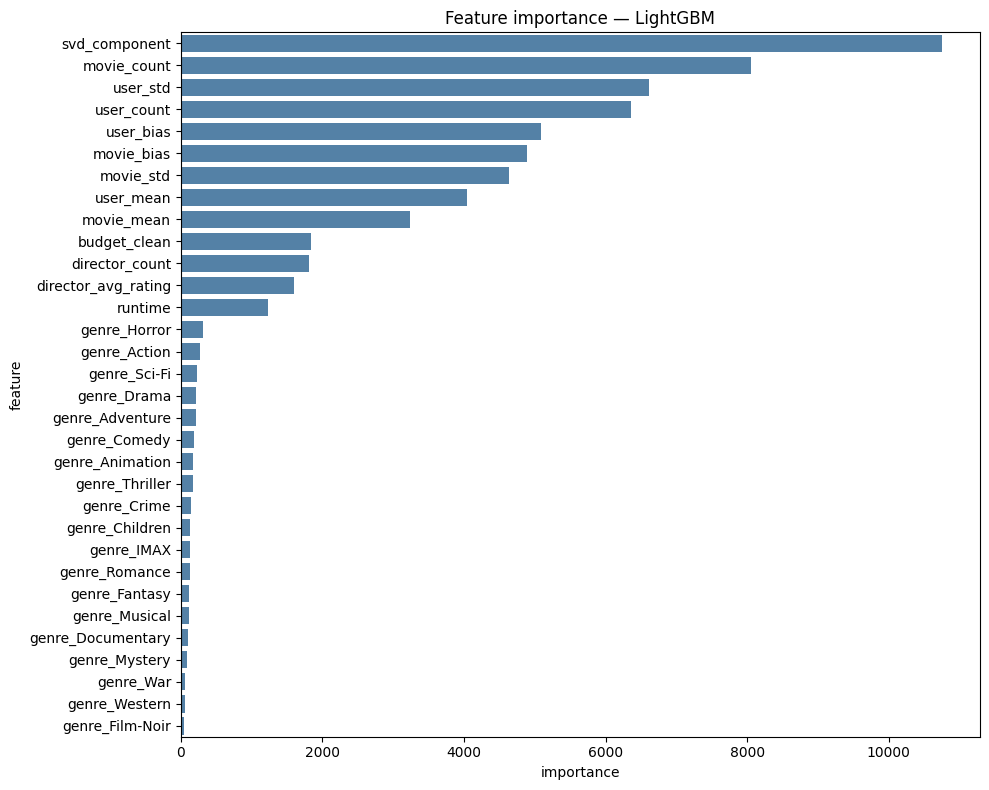

                feature  importance
8         svd_component       10753
7           movie_count        8059
3              user_std        6610
4            user_count        6364
0             user_bias        5081
1            movie_bias        4890
6             movie_std        4631
2             user_mean        4039
5            movie_mean        3234
29         budget_clean        1841
31       director_count        1807
30  director_avg_rating        1598
28              runtime        1225
19         genre_Horror         318
9          genre_Action         272
24         genre_Sci-Fi         234
16          genre_Drama         215
10      genre_Adventure         208
13         genre_Comedy         183
11      genre_Animation         173
25       genre_Thriller         168
14          genre_Crime         138
12       genre_Children         134
20           genre_IMAX         132
23        genre_Romance         123
17        genre_Fantasy         109
21        genre_Musical     

In [55]:
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance, x='importance', y='feature', color='steelblue')
plt.title('Feature importance — LightGBM')
plt.tight_layout()
plt.show()

print(importance)

In [56]:
# Load genome tags first — small file
genome_tags = pd.read_csv('data/genome_tags.csv')
print(f"Genome tags shape: {genome_tags.shape}")
print(genome_tags.head(10))

Genome tags shape: (1128, 2)
   tagId           tag
0      1           007
1      2  007 (series)
2      3  18th century
3      4         1920s
4      5         1930s
5      6         1950s
6      7         1960s
7      8         1970s
8      9         1980s
9     10  19th century


In [57]:
print("Loading genome scores... this may take 30 seconds")
genome_scores = pd.read_csv('data/genome_scores.csv')
print(f"Genome scores shape: {genome_scores.shape}")
print(genome_scores.head())


Loading genome scores... this may take 30 seconds
Genome scores shape: (15584448, 3)
   movieId  tagId  relevance
0        1      1    0.02875
1        1      2    0.02375
2        1      3    0.06250
3        1      4    0.07575
4        1      5    0.14075


In [58]:
# Calculate variance of each tag across all movies
# High variance = tag that actually distinguishes movies from each other
print("Calculating tag variance...")
tag_variance = genome_scores.groupby('tagId')['relevance'].var()
top_tags = tag_variance.nlargest(50).index.tolist()

# Get tag names for reference
top_tag_names = genome_tags[genome_tags['tagId'].isin(top_tags)]['tag'].tolist()
print(f"Top 50 most informative tags:")
print(top_tag_names)


Calculating tag variance...
Top 50 most informative tags:
['action', 'based on a book', 'bleak', 'cerebral', 'chase', 'cinematography', 'comedy', 'complex', 'corruption', 'creepy', 'crime', 'criterion', 'cult classic', 'dark', 'downbeat', 'drama', 'dramatic', 'enigmatic', 'family', 'franchise', 'fun movie', 'funny', 'golden palm', 'good action', 'great acting', 'great movie', 'horror', 'independent film', 'intimate', 'loneliness', 'love', 'love story', 'masterpiece', 'murder', 'obsession', 'oscar (best actress)', 'oscar (best directing)', 'pg-13', 'relationships', 'romantic', 'social commentary', 'special effects', 'suspense', 'suspenseful', 'talky', 'tense', 'violence', 'violent', 'visually appealing', 'weird']


In [59]:
# Filter to only top 50 tags
print("Filtering to top tags...")
genome_filtered = genome_scores[genome_scores['tagId'].isin(top_tags)]

# Pivot — rows are movies, columns are tags
print("Pivoting genome scores...")
genome_pivot = genome_filtered.pivot(index='movieId', columns='tagId', values='relevance')

# Rename columns to tag names
tag_id_to_name = genome_tags.set_index('tagId')['tag'].to_dict()
genome_pivot.columns = [f"tag_{tag_id_to_name[c]}" for c in genome_pivot.columns]
genome_pivot = genome_pivot.reset_index()

print(f"Genome feature matrix shape: {genome_pivot.shape}")
print(f"Sample columns: {genome_pivot.columns[:5].tolist()}")

Filtering to top tags...
Pivoting genome scores...
Genome feature matrix shape: (13816, 51)
Sample columns: ['movieId', 'tag_action', 'tag_based on a book', 'tag_bleak', 'tag_cerebral']


In [60]:
# Rebuild features with genome scores instead of genres
features_v2 = train_data[['userId', 'movieId', 'rating']].copy()

# User features
features_v2['user_bias'] = features_v2['userId'].map(user_bias).fillna(0)
features_v2['user_mean'] = features_v2['userId'].map(user_mean).fillna(global_mean)
features_v2['user_std'] = features_v2['userId'].map(user_std).fillna(0)
features_v2['user_count'] = features_v2['userId'].map(user_count).fillna(0)

# Movie features
features_v2['movie_bias'] = features_v2['movieId'].map(movie_bias).fillna(0)
features_v2['movie_mean'] = features_v2['movieId'].map(movie_mean).fillna(global_mean)
features_v2['movie_std'] = features_v2['movieId'].map(movie_std).fillna(0)
features_v2['movie_count'] = features_v2['movieId'].map(movie_count).fillna(0)

# SVD component
train_user_idx = features_v2['userId'].map(user_to_idx)
train_movie_idx = features_v2['movieId'].map(movie_to_idx)
features_v2['svd_component'] = predict_svd(train_user_idx, train_movie_idx)

# IMDB features
features_v2 = features_v2.merge(imdb[imdb_cols], on='movieId', how='left')
features_v2['runtime'] = features_v2['runtime'].fillna(0)
features_v2['budget_clean'] = features_v2['budget_clean'].fillna(0)
features_v2['director_avg_rating'] = features_v2['director_avg_rating'].fillna(global_mean)
features_v2['director_count'] = features_v2['director_count'].fillna(0)

# Genome features instead of genres
features_v2 = features_v2.merge(genome_pivot, on='movieId', how='left')
tag_cols = [c for c in genome_pivot.columns if c != 'movieId']
features_v2[tag_cols] = features_v2[tag_cols].fillna(0)

print(f"Feature table v2 shape: {features_v2.shape}")
print(f"Total features: {len([c for c in features_v2.columns if c not in ['userId', 'movieId', 'rating']])}")


Feature table v2 shape: (9000034, 66)
Total features: 63


Train LightGBM v2

In [61]:
feature_cols_v2 = [c for c in features_v2.columns if c not in ['userId', 'movieId', 'rating']]
X_v2 = features_v2[feature_cols_v2]
y_v2 = features_v2['rating']

print(f"Training on {len(X_v2):,} rows with {len(feature_cols_v2)} features")

model_v2 = lgb.LGBMRegressor(
    n_estimators=700,
    learning_rate=0.05,
    num_leaves=127,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model_v2.fit(
    X_v2, y_v2,
    eval_set=[(X_v2, y_v2)],
    callbacks=[lgb.log_evaluation(period=100)]
)

print("\nTraining complete")

Training on 9,000,034 rows with 63 features
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.587730 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15888
[LightGBM] [Info] Number of data points in the train set: 9000034, number of used features: 63
[LightGBM] [Info] Start training from score 3.533494
[100]	training's l2: 0.344866
[200]	training's l2: 0.333905
[300]	training's l2: 0.33073
[400]	training's l2: 0.328878
[500]	training's l2: 0.327535
[600]	training's l2: 0.326323
[700]	training's l2: 0.325241

Training complete


In [62]:
# Build validation features v2
val_v2 = val_data[['userId', 'movieId', 'rating']].copy()

val_v2['user_bias'] = val_v2['userId'].map(user_bias).fillna(0)
val_v2['user_mean'] = val_v2['userId'].map(user_mean).fillna(global_mean)
val_v2['user_std'] = val_v2['userId'].map(user_std).fillna(0)
val_v2['user_count'] = val_v2['userId'].map(user_count).fillna(0)

val_v2['movie_bias'] = val_v2['movieId'].map(movie_bias).fillna(0)
val_v2['movie_mean'] = val_v2['movieId'].map(movie_mean).fillna(global_mean)
val_v2['movie_std'] = val_v2['movieId'].map(movie_std).fillna(0)
val_v2['movie_count'] = val_v2['movieId'].map(movie_count).fillna(0)

val_user_idx = val_v2['userId'].map(user_to_idx)
val_movie_idx = val_v2['movieId'].map(movie_to_idx)
val_v2['svd_component'] = predict_svd(val_user_idx, val_movie_idx)

val_v2 = val_v2.merge(imdb[imdb_cols], on='movieId', how='left')
val_v2['runtime'] = val_v2['runtime'].fillna(0)
val_v2['budget_clean'] = val_v2['budget_clean'].fillna(0)
val_v2['director_avg_rating'] = val_v2['director_avg_rating'].fillna(global_mean)
val_v2['director_count'] = val_v2['director_count'].fillna(0)

val_v2 = val_v2.merge(genome_pivot, on='movieId', how='left')
val_v2[tag_cols] = val_v2[tag_cols].fillna(0)

# Predict
X_val_v2 = val_v2[feature_cols_v2]
val_preds_v2 = model_v2.predict(X_val_v2)
val_preds_v2 = np.clip(val_preds_v2, 0.5, 5.0)

score_v2 = rmse(val_v2['rating'], val_preds_v2)
print(f"LightGBM v2 RMSE: {score_v2:.4f}")
print(f"Improvement over v1: {0.8570 - score_v2:.4f}")


LightGBM v2 RMSE: 0.8567
Improvement over v1: 0.0003


In [64]:
model_v3 = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=127,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model_v3.fit(
    X_v2, y_v2,
    eval_set=[(X_v2, y_v2)],
    callbacks=[lgb.log_evaluation(period=100)]
)

print("\nTraining complete")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.025048 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15888
[LightGBM] [Info] Number of data points in the train set: 9000034, number of used features: 63
[LightGBM] [Info] Start training from score 3.533494
[100]	training's l2: 0.344866
[200]	training's l2: 0.333905
[300]	training's l2: 0.33073
[400]	training's l2: 0.328878
[500]	training's l2: 0.327535
[600]	training's l2: 0.326323
[700]	training's l2: 0.325241
[800]	training's l2: 0.324286
[900]	training's l2: 0.323461
[1000]	training's l2: 0.322604

Training complete


In [65]:
val_preds_v3 = model_v3.predict(X_val_v2)
val_preds_v3 = np.clip(val_preds_v3, 0.5, 5.0)

score_v3 = rmse(val_v2['rating'], val_preds_v3)
print(f"LightGBM v3 RMSE (1000 trees): {score_v3:.4f}")
print(f"Improvement over v2 (700 trees): {0.8567 - score_v3:.4f}")
print(f"Improvement over baseline: {0.8799 - score_v3:.4f}")

LightGBM v3 RMSE (1000 trees): 0.8567
Improvement over v2 (700 trees): 0.0000
Improvement over baseline: 0.0232


In [66]:
## Esemble SVD + LightGBM
# We already have both sets of validation predictions
# val_preds_v2 = LightGBM predictions
# val_data['svd_component'] + biases = SVD predictions

# Rebuild SVD predictions on validation set
val_svd_preds = (
    global_mean +
    val_v2['user_bias'] +
    val_v2['movie_bias'] +
    val_v2['svd_component']
).clip(0.5, 5.0)

# Try different blend weights
print("Blending SVD and LightGBM predictions...\n")
print(f"SVD alone:      {rmse(val_v2['rating'], val_svd_preds):.4f}")
print(f"LightGBM alone: {rmse(val_v2['rating'], val_preds_v3):.4f}")
print()

for svd_weight in [0.1, 0.2, 0.3, 0.4, 0.5]:
    lgbm_weight = 1 - svd_weight
    blended = svd_weight * val_svd_preds + lgbm_weight * val_preds_v3
    blended = blended.clip(0.5, 5.0)
    score = rmse(val_v2['rating'], blended)
    print(f"SVD {svd_weight:.0%} + LightGBM {lgbm_weight:.0%}: RMSE = {score:.4f}")

Blending SVD and LightGBM predictions...

SVD alone:      0.8685
LightGBM alone: 0.8567

SVD 10% + LightGBM 90%: RMSE = 0.8510
SVD 20% + LightGBM 80%: RMSE = 0.8469
SVD 30% + LightGBM 70%: RMSE = 0.8443
SVD 40% + LightGBM 60%: RMSE = 0.8432
SVD 50% + LightGBM 50%: RMSE = 0.8436


In [67]:
## Fine tuning the blend 

print("Fine tuning blend weight around 40%...\n")

for svd_weight in [0.35, 0.38, 0.40, 0.42, 0.45]:
    lgbm_weight = 1 - svd_weight
    blended = svd_weight * val_svd_preds + lgbm_weight * val_preds_v3
    blended = blended.clip(0.5, 5.0)
    score = rmse(val_v2['rating'], blended)
    print(f"SVD {svd_weight:.0%} + LightGBM {lgbm_weight:.0%}: RMSE = {score:.4f}")

Fine tuning blend weight around 40%...

SVD 35% + LightGBM 65%: RMSE = 0.8435
SVD 38% + LightGBM 62%: RMSE = 0.8433
SVD 40% + LightGBM 60%: RMSE = 0.8432
SVD 42% + LightGBM 58%: RMSE = 0.8431
SVD 45% + LightGBM 55%: RMSE = 0.8432


In [68]:
### Final Esemble Submission 
# Rebuild test features v2
test = pd.read_csv('data/test.csv')

test['user_bias'] = test['userId'].map(user_bias).fillna(0)
test['user_mean'] = test['userId'].map(user_mean).fillna(global_mean)
test['user_std'] = test['userId'].map(user_std).fillna(0)
test['user_count'] = test['userId'].map(user_count).fillna(0)

test['movie_bias'] = test['movieId'].map(movie_bias).fillna(0)
test['movie_mean'] = test['movieId'].map(movie_mean).fillna(global_mean)
test['movie_std'] = test['movieId'].map(movie_std).fillna(0)
test['movie_count'] = test['movieId'].map(movie_count).fillna(0)

test_user_idx = test['userId'].map(user_to_idx)
test_movie_idx = test['movieId'].map(movie_to_idx)
test['svd_component'] = predict_svd(test_user_idx, test_movie_idx)

test = test.merge(imdb[imdb_cols], on='movieId', how='left')
test['runtime'] = test['runtime'].fillna(0)
test['budget_clean'] = test['budget_clean'].fillna(0)
test['director_avg_rating'] = test['director_avg_rating'].fillna(global_mean)
test['director_count'] = test['director_count'].fillna(0)

test = test.merge(genome_pivot, on='movieId', how='left')
test[tag_cols] = test[tag_cols].fillna(0)

# LightGBM predictions
X_test_v2 = test[feature_cols_v2]
lgbm_preds = model_v3.predict(X_test_v2)
lgbm_preds = np.clip(lgbm_preds, 0.5, 5.0)

# SVD predictions
svd_preds = (
    global_mean +
    test['user_bias'] +
    test['movie_bias'] +
    test['svd_component']
).clip(0.5, 5.0)

# Blend 42% SVD + 58% LightGBM
final_preds = 0.42 * svd_preds + 0.58 * lgbm_preds
final_preds = np.clip(final_preds, 0.5, 5.0)

# Build submission
test['Id'] = test['userId'].astype(str) + '_' + test['movieId'].astype(str)
submission = pd.DataFrame({'Id': test['Id'], 'rating': final_preds})
submission.to_csv('data/submission_ensemble.csv', index=False)

print("Submission saved")
print(f"Shape: {submission.shape}")
print(f"\nPrediction stats:")
print(f"Mean: {final_preds.mean():.4f}")
print(f"Std:  {final_preds.std():.4f}")
print(f"Min:  {final_preds.min():.4f}")
print(f"Max:  {final_preds.max():.4f}")
submission.head()

Submission saved
Shape: (5000019, 2)

Prediction stats:
Mean: 3.5421
Std:  0.6744
Min:  0.5000
Max:  5.0000


,Id,rating
0,1_2011,3.709947
1,1_4144,4.451577
2,1_5767,3.701725
3,1_6711,4.151668
4,1_7318,2.893079


In [69]:
# Extract year from movie title — it's in brackets e.g. "Toy Story (1995)"
movies['release_year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)

# Convert timestamp to datetime features on train
train_data['rating_year'] = pd.to_datetime(train_data['timestamp'], unit='s').dt.year
train_data['rating_month'] = pd.to_datetime(train_data['timestamp'], unit='s').dt.month

# Merge release year onto train
train_data = train_data.merge(movies[['movieId', 'release_year']], on='movieId', how='left')

# Days since release when rated
train_data['days_since_release'] = (
    train_data['rating_year'] - train_data['release_year']
) * 365

print("Timestamp features sample:")
print(train_data[['userId', 'movieId', 'rating', 'rating_year', 'rating_month', 'release_year', 'days_since_release']].head(10))
print(f"\nRating year range: {train_data['rating_year'].min()} to {train_data['rating_year'].max()}")
print(f"Release year range: {train_data['release_year'].min()} to {train_data['release_year'].max()}")
print(f"Days since release range: {train_data['days_since_release'].min():.0f} to {train_data['days_since_release'].max():.0f}")

Timestamp features sample:
   userId  movieId  rating  rating_year  rating_month  release_year  \
0   65704     2023     3.0         1999            12        1990.0   
1   55916     4642     5.0         2016             6        2000.0   
2  114179   122912     5.0         2017            12        2018.0   
3    9463     1247     3.5         2016             4        1967.0   
4   59543     2668     3.0         2000             2        1982.0   
5   12200      527     5.0         2000             6        1993.0   
6   80082      153     3.0         1996             9        1995.0   
7   53741    56174     4.0         2018             9        2007.0   
8   19922      954     5.0         2013             6        1939.0   
9   83485    58559     4.0         2009             3        2008.0   

   days_since_release  
0              3285.0  
1              5840.0  
2              -365.0  
3             17885.0  
4              6570.0  
5              2555.0  
6               365.0  

In [70]:
## Rebuild feature table v3 with timestamp features

features_v3 = train_data[['userId', 'movieId', 'rating']].copy()

# User features
features_v3['user_bias'] = features_v3['userId'].map(user_bias).fillna(0)
features_v3['user_mean'] = features_v3['userId'].map(user_mean).fillna(global_mean)
features_v3['user_std'] = features_v3['userId'].map(user_std).fillna(0)
features_v3['user_count'] = features_v3['userId'].map(user_count).fillna(0)

# Movie features
features_v3['movie_bias'] = features_v3['movieId'].map(movie_bias).fillna(0)
features_v3['movie_mean'] = features_v3['movieId'].map(movie_mean).fillna(global_mean)
features_v3['movie_std'] = features_v3['movieId'].map(movie_std).fillna(0)
features_v3['movie_count'] = features_v3['movieId'].map(movie_count).fillna(0)

# SVD
train_user_idx = features_v3['userId'].map(user_to_idx)
train_movie_idx = features_v3['movieId'].map(movie_to_idx)
features_v3['svd_component'] = predict_svd(train_user_idx, train_movie_idx)

# IMDB
features_v3 = features_v3.merge(imdb[imdb_cols], on='movieId', how='left')
features_v3['runtime'] = features_v3['runtime'].fillna(0)
features_v3['budget_clean'] = features_v3['budget_clean'].fillna(0)
features_v3['director_avg_rating'] = features_v3['director_avg_rating'].fillna(global_mean)
features_v3['director_count'] = features_v3['director_count'].fillna(0)

# Genome
features_v3 = features_v3.merge(genome_pivot, on='movieId', how='left')
features_v3[tag_cols] = features_v3[tag_cols].fillna(0)

# Timestamp features
features_v3 = features_v3.merge(
    train_data[['userId', 'movieId', 'rating_year', 'rating_month', 'release_year', 'days_since_release']],
    on=['userId', 'movieId'],
    how='left'
)
features_v3['rating_year'] = features_v3['rating_year'].fillna(features_v3['rating_year'].median())
features_v3['rating_month'] = features_v3['rating_month'].fillna(6)
features_v3['release_year'] = features_v3['release_year'].fillna(features_v3['release_year'].median())
features_v3['days_since_release'] = features_v3['days_since_release'].fillna(0).clip(-365, 54750)

# User-genre affinity — how much does each user like each genre
print("Computing user-genre affinity...")
genre_cols_only = [f'genre_{g}' for g in genres_list]
movies_with_genres = movies[['movieId'] + genre_cols_only]
train_with_genres = train_data.merge(movies_with_genres, on='movieId', how='left')

for genre in genres_list:
    col = f'genre_{genre}'
    # Average rating this user gives to movies of this genre
    user_genre_avg = train_with_genres[train_with_genres[col] == 1].groupby('userId')['rating'].mean()
    features_v3[f'user_loves_{genre}'] = features_v3['userId'].map(user_genre_avg).fillna(global_mean)

print(f"Feature table v3 shape: {features_v3.shape}")
print(f"Total features: {len([c for c in features_v3.columns if c not in ['userId', 'movieId', 'rating']])}")

Computing user-genre affinity...
Feature table v3 shape: (9000034, 89)
Total features: 86


In [71]:
## Train LightGBM v4

feature_cols_v3 = [c for c in features_v3.columns if c not in ['userId', 'movieId', 'rating']]
X_v3 = features_v3[feature_cols_v3]
y_v3 = features_v3['rating']

print(f"Training on {len(X_v3):,} rows with {len(feature_cols_v3)} features")

model_v4 = lgb.LGBMRegressor(
    n_estimators=700,
    learning_rate=0.05,
    num_leaves=127,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model_v4.fit(
    X_v3, y_v3,
    eval_set=[(X_v3, y_v3)],
    callbacks=[lgb.log_evaluation(period=100)]
)

print("\nTraining complete")

Training on 9,000,034 rows with 86 features
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 4.431578 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20840
[LightGBM] [Info] Number of data points in the train set: 9000034, number of used features: 86
[LightGBM] [Info] Start training from score 3.533494
[100]	training's l2: 0.343189
[200]	training's l2: 0.329339
[300]	training's l2: 0.32361
[400]	training's l2: 0.320536
[500]	training's l2: 0.3182
[600]	training's l2: 0.31627
[700]	training's l2: 0.314413

Training complete


In [72]:
### Validate LightGBM v4

# Build validation features v3
val_v3 = val_data[['userId', 'movieId', 'rating']].copy()

val_v3['user_bias'] = val_v3['userId'].map(user_bias).fillna(0)
val_v3['user_mean'] = val_v3['userId'].map(user_mean).fillna(global_mean)
val_v3['user_std'] = val_v3['userId'].map(user_std).fillna(0)
val_v3['user_count'] = val_v3['userId'].map(user_count).fillna(0)

val_v3['movie_bias'] = val_v3['movieId'].map(movie_bias).fillna(0)
val_v3['movie_mean'] = val_v3['movieId'].map(movie_mean).fillna(global_mean)
val_v3['movie_std'] = val_v3['movieId'].map(movie_std).fillna(0)
val_v3['movie_count'] = val_v3['movieId'].map(movie_count).fillna(0)

val_user_idx = val_v3['userId'].map(user_to_idx)
val_movie_idx = val_v3['movieId'].map(movie_to_idx)
val_v3['svd_component'] = predict_svd(val_user_idx, val_movie_idx)

val_v3 = val_v3.merge(imdb[imdb_cols], on='movieId', how='left')
val_v3['runtime'] = val_v3['runtime'].fillna(0)
val_v3['budget_clean'] = val_v3['budget_clean'].fillna(0)
val_v3['director_avg_rating'] = val_v3['director_avg_rating'].fillna(global_mean)
val_v3['director_count'] = val_v3['director_count'].fillna(0)

val_v3 = val_v3.merge(genome_pivot, on='movieId', how='left')
val_v3[tag_cols] = val_v3[tag_cols].fillna(0)

# Timestamp features on validation set
val_data_ts = val_data.copy()
val_data_ts['rating_year'] = pd.to_datetime(val_data_ts['timestamp'], unit='s').dt.year
val_data_ts['rating_month'] = pd.to_datetime(val_data_ts['timestamp'], unit='s').dt.month
val_data_ts = val_data_ts.merge(movies[['movieId', 'release_year']], on='movieId', how='left')
val_data_ts['days_since_release'] = (val_data_ts['rating_year'] - val_data_ts['release_year']) * 365

val_v3 = val_v3.merge(
    val_data_ts[['userId', 'movieId', 'rating_year', 'rating_month', 'release_year', 'days_since_release']],
    on=['userId', 'movieId'],
    how='left'
)
val_v3['rating_year'] = val_v3['rating_year'].fillna(val_v3['rating_year'].median())
val_v3['rating_month'] = val_v3['rating_month'].fillna(6)
val_v3['release_year'] = val_v3['release_year'].fillna(val_v3['release_year'].median())
val_v3['days_since_release'] = val_v3['days_since_release'].fillna(0).clip(-365, 54750)

# User-genre affinity on validation
for genre in genres_list:
    col = f'genre_{genre}'
    user_genre_avg = train_with_genres[train_with_genres[col] == 1].groupby('userId')['rating'].mean()
    val_v3[f'user_loves_{genre}'] = val_v3['userId'].map(user_genre_avg).fillna(global_mean)

# Predict
X_val_v3 = val_v3[feature_cols_v3]
val_preds_v4 = model_v4.predict(X_val_v3)
val_preds_v4 = np.clip(val_preds_v4, 0.5, 5.0)

score_v4 = rmse(val_v3['rating'], val_preds_v4)
print(f"LightGBM v4 RMSE: {score_v4:.4f}")
print(f"Improvement over v3: {0.8567 - score_v4:.4f}")

LightGBM v4 RMSE: 0.8508
Improvement over v3: 0.0059


In [73]:
## Re-Blend esemble with v4

# Rebuild SVD predictions on validation v3
val_svd_preds_v3 = (
    global_mean +
    val_v3['user_bias'] +
    val_v3['movie_bias'] +
    val_v3['svd_component']
).clip(0.5, 5.0)

print("Blending SVD and LightGBM v4...\n")
print(f"SVD alone:          {rmse(val_v3['rating'], val_svd_preds_v3):.4f}")
print(f"LightGBM v4 alone:  {rmse(val_v3['rating'], val_preds_v4):.4f}")
print()

for svd_weight in [0.1, 0.2, 0.3, 0.4, 0.5]:
    lgbm_weight = 1 - svd_weight
    blended = svd_weight * val_svd_preds_v3 + lgbm_weight * val_preds_v4
    blended = blended.clip(0.5, 5.0)
    score = rmse(val_v3['rating'], blended)
    print(f"SVD {svd_weight:.0%} + LightGBM {lgbm_weight:.0%}: RMSE = {score:.4f}")

Blending SVD and LightGBM v4...

SVD alone:          0.8685
LightGBM v4 alone:  0.8508

SVD 10% + LightGBM 90%: RMSE = 0.8456
SVD 20% + LightGBM 80%: RMSE = 0.8420
SVD 30% + LightGBM 70%: RMSE = 0.8399
SVD 40% + LightGBM 60%: RMSE = 0.8393
SVD 50% + LightGBM 50%: RMSE = 0.8403


In [74]:
## Fine tune blend 

print("Fine tuning blend weight around 40%...\n")

for svd_weight in [0.35, 0.38, 0.40, 0.42, 0.45]:
    lgbm_weight = 1 - svd_weight
    blended = svd_weight * val_svd_preds_v3 + lgbm_weight * val_preds_v4
    blended = blended.clip(0.5, 5.0)
    score = rmse(val_v3['rating'], blended)
    print(f"SVD {svd_weight:.0%} + LightGBM {lgbm_weight:.0%}: RMSE = {score:.4f}")

Fine tuning blend weight around 40%...

SVD 35% + LightGBM 65%: RMSE = 0.8394
SVD 38% + LightGBM 62%: RMSE = 0.8393
SVD 40% + LightGBM 60%: RMSE = 0.8393
SVD 42% + LightGBM 58%: RMSE = 0.8394
SVD 45% + LightGBM 55%: RMSE = 0.8396


In [75]:
## Final ensemble submission v2

test = pd.read_csv('data/test.csv')

test['user_bias'] = test['userId'].map(user_bias).fillna(0)
test['user_mean'] = test['userId'].map(user_mean).fillna(global_mean)
test['user_std'] = test['userId'].map(user_std).fillna(0)
test['user_count'] = test['userId'].map(user_count).fillna(0)

test['movie_bias'] = test['movieId'].map(movie_bias).fillna(0)
test['movie_mean'] = test['movieId'].map(movie_mean).fillna(global_mean)
test['movie_std'] = test['movieId'].map(movie_std).fillna(0)
test['movie_count'] = test['movieId'].map(movie_count).fillna(0)

test_user_idx = test['userId'].map(user_to_idx)
test_movie_idx = test['movieId'].map(movie_to_idx)
test['svd_component'] = predict_svd(test_user_idx, test_movie_idx)

test = test.merge(imdb[imdb_cols], on='movieId', how='left')
test['runtime'] = test['runtime'].fillna(0)
test['budget_clean'] = test['budget_clean'].fillna(0)
test['director_avg_rating'] = test['director_avg_rating'].fillna(global_mean)
test['director_count'] = test['director_count'].fillna(0)

test = test.merge(genome_pivot, on='movieId', how='left')
test[tag_cols] = test[tag_cols].fillna(0)

# Timestamp features on test
test['rating_year'] = 2026
test['rating_month'] = 4
test = test.merge(movies[['movieId', 'release_year']], on='movieId', how='left')
test['days_since_release'] = (test['rating_year'] - test['release_year']) * 365
test['release_year'] = test['release_year'].fillna(test['release_year'].median())
test['days_since_release'] = test['days_since_release'].fillna(0).clip(-365, 54750)

# User-genre affinity on test
for genre in genres_list:
    col = f'genre_{genre}'
    user_genre_avg = train_with_genres[train_with_genres[col] == 1].groupby('userId')['rating'].mean()
    test[f'user_loves_{genre}'] = test['userId'].map(user_genre_avg).fillna(global_mean)

# LightGBM predictions
X_test_v3 = test[feature_cols_v3]
lgbm_preds_v4 = model_v4.predict(X_test_v3)
lgbm_preds_v4 = np.clip(lgbm_preds_v4, 0.5, 5.0)

# SVD predictions
svd_preds_v2 = (
    global_mean +
    test['user_bias'] +
    test['movie_bias'] +
    test['svd_component']
).clip(0.5, 5.0)

# Blend 40% SVD + 60% LightGBM
final_preds_v2 = 0.40 * svd_preds_v2 + 0.60 * lgbm_preds_v4
final_preds_v2 = np.clip(final_preds_v2, 0.5, 5.0)

# Build submission
test['Id'] = test['userId'].astype(str) + '_' + test['movieId'].astype(str)
submission_v2 = pd.DataFrame({'Id': test['Id'], 'rating': final_preds_v2})
submission_v2.to_csv('data/submission_ensemble_v2.csv', index=False)

print("Submission saved")
print(f"Shape: {submission_v2.shape}")
print(f"Mean prediction: {final_preds_v2.mean():.4f}")
print(f"Std: {final_preds_v2.std():.4f}")
submission_v2.head()

Submission saved
Shape: (5000019, 2)
Mean prediction: 3.5507
Std: 0.6718


,Id,rating
0,1_2011,3.676739
1,1_4144,4.359247
2,1_5767,3.604027
3,1_6711,4.083898
4,1_7318,2.916092


In [76]:
## Train multiple SVD components

print("Training SVD at K=50...")
U50, sigma50, Vt50 = svds(rating_matrix, k=50)
sigma50 = np.diag(sigma50)
U50_sigma = np.dot(U50, sigma50)

print("Training SVD at K=100 (already done, reusing)...")
U100_sigma = U_sigma  # from earlier

print("Training SVD at K=200...")
U200, sigma200, Vt200 = svds(rating_matrix, k=200)
sigma200 = np.diag(sigma200)
U200_sigma = np.dot(U200, sigma200)

print("All SVD components ready")

Training SVD at K=50...
Training SVD at K=100 (already done, reusing)...
Training SVD at K=200...
All SVD components ready


In [77]:
## Multi-SVD prediction functions 

def predict_svd50(user_idx_series, movie_idx_series):
    predictions = np.zeros(len(user_idx_series))
    known_mask = user_idx_series.notna() & movie_idx_series.notna()
    u_idx = user_idx_series[known_mask].astype(int).values
    m_idx = movie_idx_series[known_mask].astype(int).values
    predictions[known_mask] = np.sum(U50_sigma[u_idx] * Vt50.T[m_idx], axis=1)
    return predictions

def predict_svd100(user_idx_series, movie_idx_series):
    predictions = np.zeros(len(user_idx_series))
    known_mask = user_idx_series.notna() & movie_idx_series.notna()
    u_idx = user_idx_series[known_mask].astype(int).values
    m_idx = movie_idx_series[known_mask].astype(int).values
    predictions[known_mask] = np.sum(U100_sigma[u_idx] * Vt.T[m_idx], axis=1)
    return predictions

def predict_svd200(user_idx_series, movie_idx_series):
    predictions = np.zeros(len(user_idx_series))
    known_mask = user_idx_series.notna() & movie_idx_series.notna()
    u_idx = user_idx_series[known_mask].astype(int).values
    m_idx = movie_idx_series[known_mask].astype(int).values
    predictions[known_mask] = np.sum(U200_sigma[u_idx] * Vt200.T[m_idx], axis=1)
    return predictions

print("SVD prediction functions ready")


SVD prediction functions ready


In [78]:
import numpy as np

# Add timestamp to train_data if not already there
train_data['rating_year'] = pd.to_datetime(train_data['timestamp'], unit='s').dt.year

# Recency weight — ratings decay exponentially with age
# A rating from 2019 gets weight 1.0, a rating from 2009 gets weight ~0.37
max_year = train_data['rating_year'].max()
train_data['recency_weight'] = np.exp(
    (train_data['rating_year'] - max_year) / 10
)

# Weighted user bias
def weighted_bias(df, group_col, lambda_reg=15):
    grouped = df.groupby(group_col)
    weighted_sum = grouped.apply(
        lambda x: ((x['rating'] - global_mean) * x['recency_weight']).sum()
    )
    weighted_count = grouped['recency_weight'].sum()
    return weighted_sum / (weighted_count + lambda_reg)

print("Computing recency-weighted biases...")
user_bias_weighted = weighted_bias(train_data, 'userId')
movie_bias_weighted = weighted_bias(train_data, 'movieId')

print(f"User bias range: {user_bias_weighted.min():.3f} to {user_bias_weighted.max():.3f}")
print(f"Movie bias range: {movie_bias_weighted.min():.3f} to {movie_bias_weighted.max():.3f}")

Computing recency-weighted biases...
User bias range: -2.635 to 1.455
Movie bias range: -2.134 to 0.941
